# **RIDGE regression**

Marek Šugár

Here we evaluated the near-optimal settings for the model in terms of the best performing <code>MAPE</code>. We have implemented sequential grid search for <code>Training Window</code> length and $\lambda$ regularization parameter.

Particular stocks included in this analysis were **TOP 2** and **BOTTOM 2** stocks in terms of <code>MAPE</code> in the very first model created with default regularization parameter and **Training Window** length 8.

We include heat-map visuals to better comprehend the behaviour observed.

In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Ridge

# In case of convergence problem, supress warning
import warnings

#warnings.filterwarnings("ignore")

In [5]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **RIDGE regression**

In [ ]:
performance_trackerENPH = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:
    for window_length in range(2, 31):
        for ticker in ["ENPH"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerENPH[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/4239538046.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

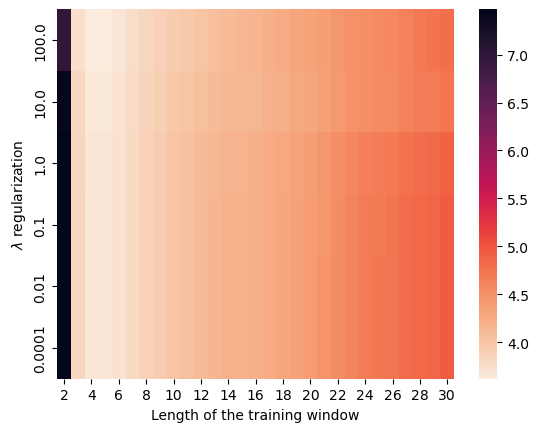

In [7]:
df = pd.Series(performance_trackerENPH).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [8]:
np.argmin(list(performance_trackerENPH.values()))

np.int64(147)

In [9]:
performance_trackerROP = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["ROP"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerROP[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.3888574703410956
(0.0001, 3) 1.1728546578309513
(0.0001, 4) 1.1094679075112046
(0.0001, 5) 1.110110917136313
(0.0001, 6) 1.1197522490616123
(0.0001, 7) 1.1393536643013262
(0.0001, 8) 1.1550424086231001
(0.0001, 9) 1.173358327362257
(0.0001, 10) 1.1976711396846311
(0.0001, 11) 1.203958960453443
(0.0001, 12) 1.2089069226508407
(0.0001, 13) 1.2259530241281955
(0.0001, 14) 1.239615031840797
(0.0001, 15) 1.2510328270925184
(0.0001, 16) 1.260811649153281
(0.0001, 17) 1.2689263498511825
(0.0001, 18) 1.2826620809318046
(0.0001, 19) 1.2927053017224208
(0.0001, 20) 1.3089952947325936
(0.0001, 21) 1.327062748340408
(0.0001, 22) 1.3309799585927764
(0.0001, 23) 1.3451036033810932
(0.0001, 24) 1.3619678304750187
(0.0001, 25) 1.3669619838277212
(0.0001, 26) 1.381535198744778
(0.0001, 27) 1.3870217083953822
(0.0001, 28) 1.3919715203412824
(0.0001, 29) 1.3955218034423587
(0.0001, 30) 1.3931865211932142
(0.01, 2) 2.3888391859910216
(0.01, 3) 1.172850665926273
(0.01, 4) 1.1094645762023925
(

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/508553450.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

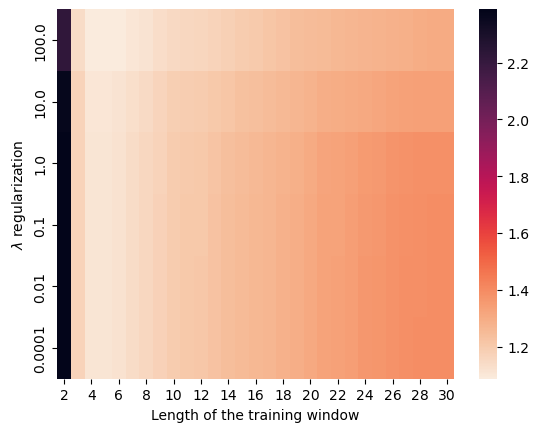

In [10]:
df = pd.Series(performance_trackerROP).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [11]:
np.argmin(list(performance_trackerROP.values()))

np.int64(148)

In [12]:
performance_trackerSMCI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["SMCI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerSMCI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 6.054523775254048
(0.0001, 3) 3.1744923043805615
(0.0001, 4) 3.0192484590833257
(0.0001, 5) 3.067771801609453
(0.0001, 6) 3.1058276367183173
(0.0001, 7) 3.1797233186088842
(0.0001, 8) 3.240007307843392
(0.0001, 9) 3.3095691520539323
(0.0001, 10) 3.4020213293475736
(0.0001, 11) 3.4432770785767994
(0.0001, 12) 3.504013445970579
(0.0001, 13) 3.6163656803285558
(0.0001, 14) 3.625720151053595
(0.0001, 15) 3.6437208656628215
(0.0001, 16) 3.6904709491215604
(0.0001, 17) 3.702957277574957
(0.0001, 18) 3.7248317764106416
(0.0001, 19) 3.7974194890337745
(0.0001, 20) 3.8244703082022444
(0.0001, 21) 3.862662941361357
(0.0001, 22) 3.8980343251491414
(0.0001, 23) 3.906704660779758
(0.0001, 24) 3.9492546405820446
(0.0001, 25) 3.9626032500188497
(0.0001, 26) 4.001775557478208
(0.0001, 27) 4.0591524771236545
(0.0001, 28) 4.099114894237333
(0.0001, 29) 4.128580582718861
(0.0001, 30) 4.1299708554512335
(0.01, 2) 6.054479786252661
(0.01, 3) 3.174482442831202
(0.01, 4) 3.0192395107771866
(0.01,

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/2340393621.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

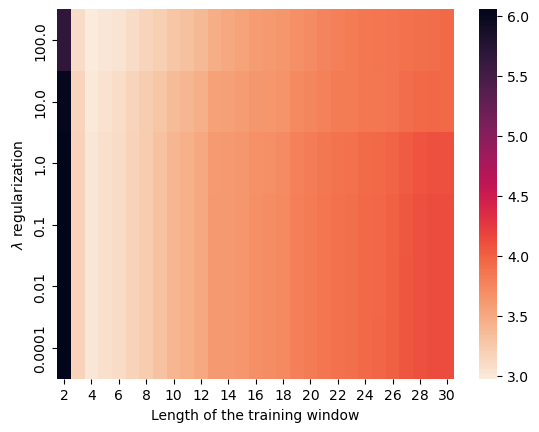

In [13]:
df = pd.Series(performance_trackerSMCI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [14]:
np.argmin(list(performance_trackerSMCI.values()))

np.int64(147)

In [15]:
performance_trackerMSI = {}

for Alpha in [0.0001, 0.01, 0.1, 1, 10, 100]:#np.logspace(-4, 2, 50):
    for window_length in range(2, 31):
        for ticker in ["MSI"]:
            Stock_Data = pd.read_sql(
                f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
                con=StockDataDatabase, parse_dates=["Date"]
            )
            
            Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
            Stock_Data["Target"] = Stock_Data["Close"]
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            training_length = window_length
            prediction_length = 1

            MAPEs = []

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                # Define feature and target windows
                Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

                Test_Features = Stock_Data[historic_columns].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]
                Test_Target = Stock_Data["Target"].iloc[
                    window_start+training_length : window_start+training_length+prediction_length
                ]

                # Skip empty slices
                if Training_Features.empty or Test_Features.empty:
                    continue
            
                # Scale only selected features
                scaler = StandardScaler()
                Training_Features = scaler.fit_transform(Training_Features)
                Test_Features = scaler.transform(Test_Features)

                # Fit KNN
                MODEL = Ridge(alpha=Alpha)
                MODEL.fit(Training_Features, Training_Target)

                # Predict and evaluate
                prediction = MODEL.predict(Test_Features)
                MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
            
            # Save results
            performance_trackerMSI[(Alpha, window_length)] = np.mean(MAPEs)
            print((Alpha, window_length), np.mean(MAPEs))


(0.0001, 2) 2.554911675116331
(0.0001, 3) 1.269183360685145
(0.0001, 4) 1.2095117854262265
(0.0001, 5) 1.2000261413656599
(0.0001, 6) 1.204138232846771
(0.0001, 7) 1.2250502103136285
(0.0001, 8) 1.2451810193624941
(0.0001, 9) 1.2659121762093026
(0.0001, 10) 1.2669472278512435
(0.0001, 11) 1.2891816687299587
(0.0001, 12) 1.2924567815577805
(0.0001, 13) 1.3007943590778523
(0.0001, 14) 1.3120385896501314
(0.0001, 15) 1.3106603547071989
(0.0001, 16) 1.328609665191965
(0.0001, 17) 1.3462375069914283
(0.0001, 18) 1.3550998809651238
(0.0001, 19) 1.367010034185982
(0.0001, 20) 1.3803190041290678
(0.0001, 21) 1.4047490381683005
(0.0001, 22) 1.421747154869126
(0.0001, 23) 1.441669600697057
(0.0001, 24) 1.4572341161186728
(0.0001, 25) 1.4693263674839259
(0.0001, 26) 1.4846771747378593
(0.0001, 27) 1.5012170465380739
(0.0001, 28) 1.5143706054344095
(0.0001, 29) 1.5202434934708706
(0.0001, 30) 1.5235251070439588
(0.01, 2) 2.5548923925518134
(0.01, 3) 1.2691784867631213
(0.01, 4) 1.2095069635885867


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hd/lvkyz8053vg15hx2z_h9tsnh0000gn/T/ipykernel_1292/2595922068.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda$ regularization")


Text(50.722222222222214, 0.5, '$\\lambda$ regularization')

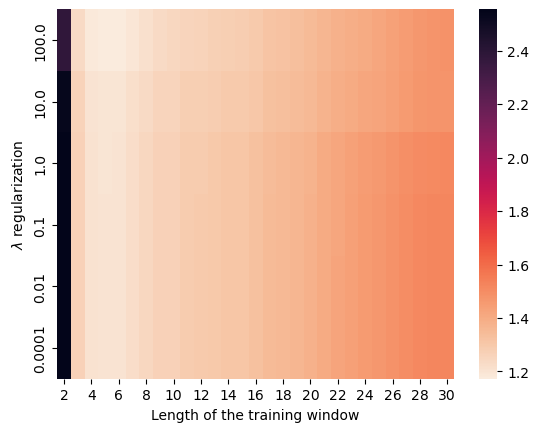

In [16]:
df = pd.Series(performance_trackerMSI).unstack()

sns.heatmap(df, cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of the training window")
plt.ylabel("$\lambda$ regularization")

In [20]:
print(np.argmin(list(performance_trackerENPH.values())))
print(np.argmin(list(performance_trackerSMCI.values())))
print(np.argmin(list(performance_trackerROP.values())))
print(np.argmin(list(performance_trackerMSI.values())))

# V oboch prípadoch dostávame argmin hodnoty
# 147 -> (100, 4)
# 148 -> (100, 5)
# Vykonáme validáciu a porovnáme priemernú odchýlku pre obe
# dvojice parameterov 

list(performance_trackerROP.keys())[148]

147
147
148
148


(100, 5)